# Classificação de Faixas Explícitas no Spotify (2024)

**Objetivo:**  
Construir um modelo de classificação binária que, a partir das métricas de streaming e presença em plataformas, prevê se uma música é _Explicit_ (`True`) ou _Non-Explicit_ (`False`).

**Conteúdo deste notebook:**
1. Introdução e contexto  
2. Importação de bibliotecas  
3. Carga dos dados via URL  
4. Análise Exploratória (EDA)  
5. Pré-processamento  
6. Modelagem e otimização de hiperparâmetros  
7. Avaliação comparativa dos modelos  
8. Exportação do modelo final  


## 1. Descrição do Dataset

- Fontes:

1.   Original: [Kaggle – Most Streamed Spotify Songs 2024](https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024/data)
2.   Modificada: [MVP - Most Streamed Spotify Songs 2024 v2](https://raw.githubusercontent.com/brunocastrillon/pos-puc-sprint02-ml/master/model/dataset/most_streamed_spotify_songs_2024_v2.csv)

- Novo atributo alvo: `Explicit Classified` (0 ou 1)
- Colunas principais de interesse: métricas numéricas de plataformas, como streams, likes e popularidade.

## 2. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")

## 3. Carga e Limpeza dos Dados

In [2]:
# URL do dataset
DATA_URL = "https://raw.githubusercontent.com/brunocastrillon/pos-puc-sprint02-ml/master/model/dataset/most_streamed_spotify_songs_2024.csv"

# Função de carga com remoção de milhares e conversão para numérico
def load_and_clean(url):
    df = pd.read_csv(url, thousands=",", encoding="latin-1")
    # Lista de colunas numéricas a tratar
    cols = [c for c in df.columns if c not in ["Track", "Album Name", "Artist", "Release Date",
                                                "ISRC", "Explicit Track", "Explicit Classified"]]
    for c in cols:
        df[c] = df[c].astype(str).str.replace(",", "", regex=False)
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

df = load_and_clean(DATA_URL)

# dropa colunas vazias
df.dropna(axis=1, how='all', inplace=True)

df["Explicit Classified"] = df["Explicit Classified"].astype(int)

df.head()

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,Explicit Track,Explicit Classified
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,3.904709e+08,30716.0,196631588.0,...,684.0,62.0,17598718.0,114.0,18004655.0,22931.0,4818457.0,2669262.0,0,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,3.237039e+08,28113.0,174597137.0,...,3.0,67.0,10422430.0,111.0,7780028.0,28444.0,6623075.0,1118279.0,1,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,6.013093e+08,54331.0,211607669.0,...,536.0,136.0,36321847.0,172.0,5022621.0,5639.0,7208651.0,5285340.0,0,1
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,2.031281e+09,269802.0,136569078.0,...,2182.0,264.0,24684248.0,210.0,190260277.0,203384.0,NaN,11822942.0,0,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,1.070349e+08,7223.0,151469874.0,...,1.0,82.0,17660624.0,105.0,4493884.0,7006.0,207179.0,457017.0,1,1


## 4. Exploração de Dados (EDA)

Nesta seção vamos:
1. Correlação entre métricas de plataformas.  
2. Métricas de impacto por artista.  


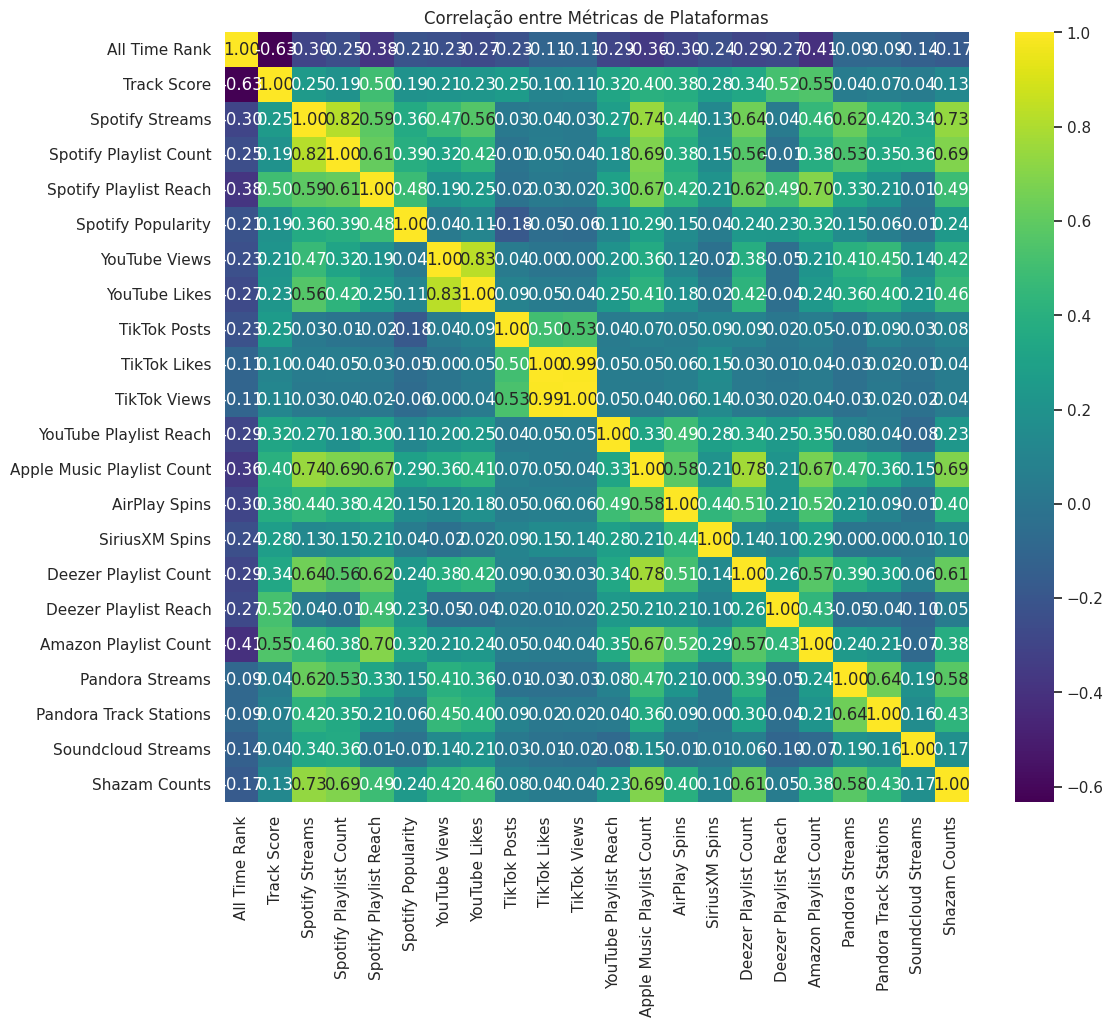

In [3]:
# 4.1 Correlação entre métricas de plataformas
platform_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                 if c not in ["Explicit Track", "Explicit Classified"]]

corr = df[platform_cols].dropna(axis=1, how="all").corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis")
plt.title("Correlação entre Métricas de Plataformas")
plt.show()

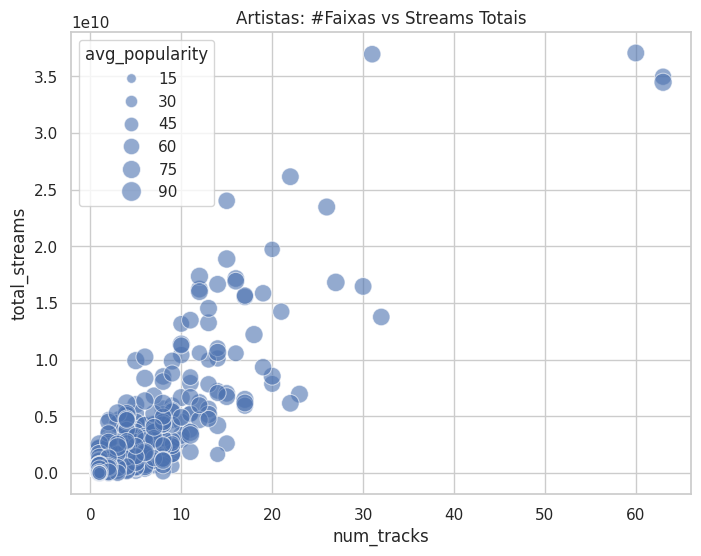

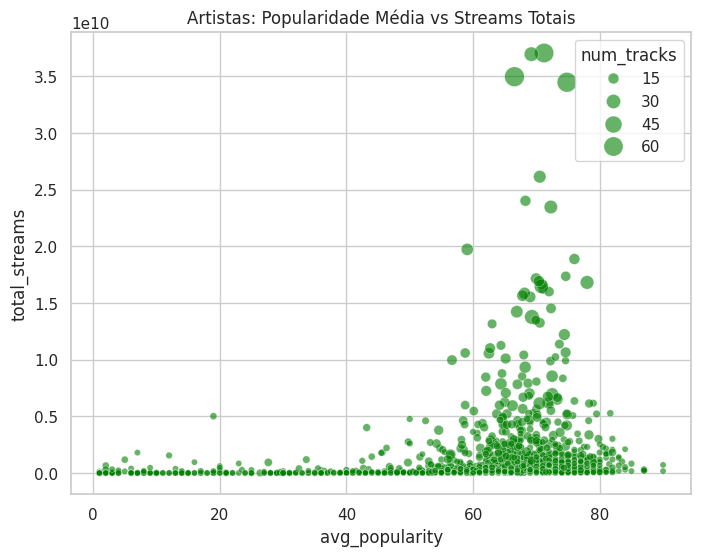

In [4]:
# 4.2 Métricas de impacto por artista
artist_metrics = df.groupby("Artist").agg(
    total_streams=("Spotify Streams", "sum"),
    avg_popularity=("Spotify Popularity", "mean"),
    num_tracks=("Artist", "count")
).reset_index()

plt.figure(figsize=(8,6))
sns.scatterplot(data=artist_metrics, x="num_tracks", y="total_streams",
                size="avg_popularity", sizes=(20,200), alpha=0.6)
plt.title("Artistas: #Faixas vs Streams Totais")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=artist_metrics, x="avg_popularity", y="total_streams",
                size="num_tracks", sizes=(20,200), alpha=0.6, color="green")
plt.title("Artistas: Popularidade Média vs Streams Totais")
plt.show()

## 5. Preparação de Dados para Modelagem

Nesta seção vamos:
1. Selecionar as features que alimentam nossos modelos.  
2. Dividir o dataset em treino e teste (hold-out).  


In [5]:
# Definição de features e target
TARGET = "Explicit Classified"
features = [c for c in platform_cols if c in df.columns]

X = df[features]
y = df[TARGET].astype(int)

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Features utilizadas:", features)

Features utilizadas: ['All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts']


## 6. Treinamento e Otimização de Hiperparâmetros

Nesta seção vamos:
1. Definir pipelines completos (escalonamento + classificador) para cada algoritmo.
2. Definir grades de hiperparâmetros para GridSearchCV.  
3. Buscar os melhores parâmetros via validação cruzada (cv=5).

In [6]:
# Criação de pipelines
pipelines = {
    'knn': Pipeline([('imputer', SimpleImputer()), ('scaler', StandardScaler()), ('model', KNeighborsClassifier())]),
    'decision_tree': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42))]),
    'naive_bayes': Pipeline([('imputer', SimpleImputer()), ('scaler', StandardScaler()), ('model', GaussianNB())]),
    'svm': Pipeline([('imputer', SimpleImputer()), ('scaler', StandardScaler()), ('model', SVC(class_weight='balanced', probability=True, random_state=42))])
}

params = {
    'knn': {'model__n_neighbors': [3,5,7,9]},
    'decision_tree': {'model__max_depth': [3,5,10,None]},
    'naive_bayes': {'model__var_smoothing': [1e-9,1e-8,1e-7]},
    'svm': {'model__C': [0.1,1,10], 'model__kernel': ['linear','rbf'], 'model__gamma': ['scale','auto']}
}

best_models = {}
for name, pipe in pipelines.items():
    print(f"Treinando {name}...")
    grid = GridSearchCV(pipe, params[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Melhor {name}: {grid.best_score_:.4f} com {grid.best_params_}\n")

Treinando knn...
Melhor knn: 0.7481 com {'model__n_neighbors': 7}

Treinando decision_tree...
Melhor decision_tree: 0.6788 com {'model__max_depth': None}

Treinando naive_bayes...
Melhor naive_bayes: 0.4508 com {'model__var_smoothing': 1e-09}

Treinando svm...
Melhor svm: 0.7337 com {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}



## 7. Avaliação dos Modelos

Nesta seção vamos avaliar cada estimador otimizado no conjunto de **teste**:
- Acurácia final
- Relatório de classificação (precision, recall, f1-score)
- Matriz de confusão

In [7]:
for name, model in best_models.items():
    print(f"Avaliando {name}...")
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Acurácia: {acc:.4f} ({acc*100:.2f}%)")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred), "\n")

Avaliando knn...
Acurácia: 0.7370 (73.70%)
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       663
           1       0.55      0.34      0.42       257

    accuracy                           0.74       920
   macro avg       0.66      0.61      0.62       920
weighted avg       0.71      0.74      0.72       920

[[591  72]
 [170  87]] 

Avaliando decision_tree...
Acurácia: 0.6913 (69.13%)
              precision    recall  f1-score   support

           0       0.78      0.79      0.79       663
           1       0.45      0.44      0.44       257

    accuracy                           0.69       920
   macro avg       0.62      0.61      0.61       920
weighted avg       0.69      0.69      0.69       920

[[523 140]
 [144 113]] 

Avaliando naive_bayes...
Acurácia: 0.4489 (44.89%)
              precision    recall  f1-score   support

           0       0.82      0.30      0.44       663
           1       0.31      0.82      0

## 8. Seleção do Melhor Modelo e Exportação

1. Identificamos o modelo com maior acurácia no conjunto de teste.  
2. Exportamos esse modelo para uso na aplicação back-end.

In [8]:
# Selecionar melhor modelo
best_name = max(best_models, key=lambda n: accuracy_score(y_test, best_models[n].predict(X_test)))
best_model = best_models[best_name]
print(f"Melhor modelo selecionado: {best_name}")

# Salvar artefato
artifact = {
    'model': best_model,
    'platform_correlation': corr,
    'artist_metrics': artist_metrics,
    'feature_names': features
}
joblib.dump(artifact, "output_model.pkl")
print("Artefato salvo: output_model.pkl")

Melhor modelo selecionado: knn
Artefato salvo: artifact_spotify_mvp_v2.pkl
